# Pneumonia Predictor
Run this notebook block-by-block.


## Imports
Import required libraries.


In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from tqdm import tqdm
import os
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, matthews_corrcoef
import seaborn as sns
import numpy as np
from pathlib import Path
import logging
from typing import Dict, Tuple, List
import time
import datetime
import argparse

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)


## Model Class
Define the ResNet50-based Pneumonia Classifier pipeline.


In [26]:
class PneumoniaClassifier:
    """A comprehensive pneumonia classification model using ResNet50."""

    def __init__(self, data_dir: str, num_classes: int = 2, batch_size: int = 32,
                 learning_rate: float = 0.001, num_workers: int = 0):
        """
        Initialize the pneumonia classifier.

        Args:
            data_dir: Path to the dataset directory
            num_classes: Number of classes (default: 2 for normal/pneumonia)
            batch_size: Batch size for training and validation
            learning_rate: Learning rate for optimization
            num_workers: Number of workers for data loading
        """
        self.data_dir = Path(data_dir)
        self.num_classes = num_classes
        self.batch_size = batch_size
        self.learning_rate = learning_rate
        self.num_workers = num_workers
        try:
            import torch_directml
            self.device = torch_directml.device()
            logger.info(f"Using device: {self.device} (DirectML GPU)")
        except ImportError:
            self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
            logger.info(f"Using device: {self.device} (Fallback)")

        logger.info(f"Using device: {self.device}")
        logger.info(f"Data directory: {self.data_dir}")

        # Initialize model components
        self.model = None
        self.criterion = None
        self.optimizer = None
        self.scheduler = None
        self.dataloaders = None
        self.dataset_sizes = None
        self.class_names = None
        self.class_weights = None

        # Training history
        self.train_losses = []
        self.val_losses = []
        self.train_accuracies = []
        self.val_accuracies = []

    def setup_data_transforms(self) -> Dict[str, transforms.Compose]:
        """Set up data transformations for training and validation."""
        data_transforms = {
            'train': transforms.Compose([
                transforms.Resize((256, 256)),
                transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.RandomVerticalFlip(p=0.1), # Added vertical flip
                transforms.RandomRotation(degrees=20), # Increased rotation
                transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)), # Added affine
                transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
                transforms.ToTensor(),
                transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
            ]),
            'val': transforms.Compose([
                transforms.Resize((256, 256)),
                transforms.CenterCrop(224),
                transforms.ToTensor(),
                transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
            ]),
            'test': transforms.Compose([
                transforms.Resize((256, 256)),
                transforms.CenterCrop(224),
                transforms.ToTensor(),
                transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
            ])
        }
        return data_transforms

    def load_data(self):
        """Load and prepare the dataset."""
        try:
            data_transforms = self.setup_data_transforms()

            # Check which splits exist
            available_splits = []
            for split in ['train', 'val', 'test']:
                split_path = self.data_dir / split
                if split_path.exists():
                    available_splits.append(split)
                    logger.info(f"Found {split} split at {split_path}")
                else:
                    logger.warning(f"Split '{split}' not found at {split_path}")

            if not available_splits:
                raise FileNotFoundError(f"No data splits found in {self.data_dir}")

            # Load datasets
            image_datasets = {}
            for split in available_splits:
                image_datasets[split] = datasets.ImageFolder(
                    root=self.data_dir / split,
                    transform=data_transforms[split]
                )

            # Create data loaders
            self.dataloaders = {}
            self.dataset_sizes = {}

            for split in available_splits:
                shuffle = (split == 'train')
                self.dataloaders[split] = DataLoader(
                    image_datasets[split],
                    batch_size=self.batch_size,
                    shuffle=shuffle,
                    num_workers=self.num_workers,
                    pin_memory=True if self.device.type == 'cuda' else False
                )
                self.dataset_sizes[split] = len(image_datasets[split])

            self.datasets = image_datasets
            self.class_names = image_datasets[available_splits[0]].classes

            # Calculate class weights for imbalance
            if 'train' in image_datasets:
                train_dataset = image_datasets['train']
                targets = [s[1] for s in train_dataset.samples]
                class_counts = np.bincount(targets)
                total_samples = len(targets)
                weights = total_samples / (len(class_counts) * class_counts)
                self.class_weights = torch.tensor(weights, dtype=torch.float).to(self.device)
                logger.info(f"Calculated class weights: {self.class_weights.cpu().numpy()}")

            # Print dataset information
            logger.info("Dataset loaded successfully!")
            logger.info(f"Class names: {self.class_names}")
            for split in available_splits:
                logger.info(f"{split.capitalize()} set size: {self.dataset_sizes[split]}")

        except Exception as e:
            logger.error(f"Error loading data: {str(e)}")
            raise

    def build_model(self):
        """Build and configure the ResNet50 model."""
        try:
            # Load pre-trained ResNet50
            self.model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

            # Freeze early layers (optional - can be unfrozen for fine-tuning)
            for param in self.model.parameters():
                param.requires_grad = False

            # Replace the final fully connected layer
            num_ftrs = self.model.fc.in_features
            self.model.fc = nn.Sequential(
                nn.Dropout(0.5),
                nn.Linear(num_ftrs, 512),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(512, self.num_classes)
            )

            # Enable gradients for the new classifier layers
            for param in self.model.fc.parameters():
                param.requires_grad = True

            self.model = self.model.to(self.device)

            # Set up loss function with class weights
            self.criterion = nn.CrossEntropyLoss(weight=self.class_weights).to(self.device)
            self.optimizer = optim.AdamW(
                filter(lambda p: p.requires_grad, self.model.parameters()),
                lr=self.learning_rate,
                weight_decay=0.01
            )

            # Set up learning rate scheduler
            self.scheduler = optim.lr_scheduler.StepLR(
                self.optimizer, step_size=7, gamma=0.1
            )

            logger.info("Model built successfully!")
            logger.info(f"Model parameters: {sum(p.numel() for p in self.model.parameters() if p.requires_grad):,}")

        except Exception as e:
            logger.error(f"Error building model: {str(e)}")
            raise

    def unfreeze_model(self, layers_to_unfreeze: int = 2):
        """
        Unfreeze the last N blocks of the ResNet50 model for fine-tuning.
        layers_to_unfreeze: 1 for layer4, 2 for layer3 & layer4, etc.
        """
        if self.model is None:
            logger.error("Build the model before unfreezing.")
            return

        logger.info(f"Unfreezing the last {layers_to_unfreeze} layers of the model...")

        # Unfreeze specified layers
        if layers_to_unfreeze >= 1:
            for param in self.model.layer4.parameters():
                param.requires_grad = True
        if layers_to_unfreeze >= 2:
            for param in self.model.layer3.parameters():
                param.requires_grad = True
        if layers_to_unfreeze >= 3:
            for param in self.model.layer2.parameters():
                param.requires_grad = True
        if layers_to_unfreeze >= 4:
            for param in self.model.parameters():
                param.requires_grad = True

        # Re-initialize optimizer to include new parameters
        self.optimizer = optim.AdamW(
            filter(lambda p: p.requires_grad, self.model.parameters()),
            lr=self.learning_rate / 10, # Use a smaller learning rate for fine-tuning
            weight_decay=0.01
        )

        logger.info(f"New trainable parameters: {sum(p.numel() for p in self.model.parameters() if p.requires_grad):,}")

    def train_epoch(self, phase: str) -> Tuple[float, float]:
        """Train or validate for one epoch."""
        if phase == 'train':
            self.model.train()
        else:
            self.model.eval()

        running_loss = 0.0
        running_corrects = 0

        progress_bar = tqdm(self.dataloaders[phase], desc=f'{phase.capitalize()}')

        for inputs, labels in progress_bar:
            inputs = inputs.to(self.device, non_blocking=True)
            labels = labels.to(self.device, non_blocking=True)

            self.optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = self.model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = self.criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    self.optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

            # Update progress bar
            current_loss = running_loss / ((progress_bar.n + 1) * self.batch_size)
            current_acc = running_corrects.float() / ((progress_bar.n + 1) * self.batch_size)
            progress_bar.set_postfix({
                'Loss': f'{current_loss:.4f}',
                'Acc': f'{current_acc:.4f}'
            })

        epoch_loss = running_loss / self.dataset_sizes[phase]
        epoch_acc = running_corrects.float() / self.dataset_sizes[phase]

        return epoch_loss, epoch_acc

    def train(self, num_epochs: int = 25, save_path: str = 'best_pneumonia_model.pth', early_stopping_patience: int = 5):
        """Train the model."""
        if self.model is None or self.dataloaders is None:
            raise RuntimeError("Model and data must be loaded before training")

        logger.info(f"Starting training for {num_epochs} epochs...")
        start_time = time.time()

        best_model_wts = self.model.state_dict().copy()
        best_acc = 0.0
        best_loss_for_es = float('inf')
        epochs_no_improve = 0

        for epoch in range(num_epochs):
            logger.info(f'Epoch {epoch+1}/{num_epochs}')
            logger.info('-' * 10)

            # Each epoch has a training and validation phase
            for phase in ['train', 'val']:
                if phase not in self.dataloaders:
                    continue

                epoch_loss, epoch_acc = self.train_epoch(phase)

                logger.info(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

                # Store training history
                if phase == 'train':
                    self.train_losses.append(epoch_loss)
                    self.train_accuracies.append(epoch_acc.cpu().numpy())
                else:
                    self.val_losses.append(epoch_loss)
                    self.val_accuracies.append(epoch_acc.cpu().numpy())

                    # Deep copy the model if it's the best so far
                    if epoch_acc > best_acc:
                        best_acc = epoch_acc
                        best_model_wts = self.model.state_dict().copy()
                        logger.info(f'New best model! Validation Acc: {best_acc:.4f}')

                        # IMMEDIATE SAVE (Ensures 94% is not lost if training stops/restarts later)
                        self._save_checkpoint(best_model_wts, best_acc, save_path)

                    # Early stopping tracking
                    if epoch_loss < best_loss_for_es:
                        best_loss_for_es = epoch_loss
                        epochs_no_improve = 0
                    else:
                        epochs_no_improve += 1

            # Step the scheduler
            if 'val' in self.dataloaders:
                self.scheduler.step()

            logger.info('')

            if epochs_no_improve >= early_stopping_patience:
                logger.info(f'Early stopping triggered after {epoch+1} epochs!')
                break

        training_time = time.time() - start_time
        logger.info(f'Training finished in {training_time // 60:.0f}m {training_time % 60:.0f}s')

        # Load best model weights and do final sync
        self.model.load_state_dict(best_model_wts)
        self._save_checkpoint(best_model_wts, best_acc, save_path)

    def _save_checkpoint(self, weights, accuracy, path):
        """Internal helper to safely write the brain to disk."""
        try:
            save_dict = {
                'model_state_dict': weights,
                'class_names': self.class_names,
                'num_classes': self.num_classes,
                'best_acc': float(accuracy),
                'training_history': {
                    'train_losses': self.train_losses,
                    'val_losses': self.val_losses,
                    'train_accuracies': self.train_accuracies,
                    'val_accuracies': self.val_accuracies
                }
            }
            if hasattr(self, 'last_results') and self.last_results is not None:
                save_dict['last_results'] = self.last_results

            if self.class_weights is not None:
                save_dict['class_weights'] = self.class_weights.cpu().numpy()

            torch.save(save_dict, path)
            logger.info(f'Model weights synchronized to disk: {path} (Acc: {accuracy:.2%})')
        except Exception as e:
            logger.error(f"Error saving checkpoint: {str(e)}")

    def evaluate(self, phase: str = 'test') -> Dict:
        """Evaluate the model and return detailed metrics."""
        if phase not in self.dataloaders:
            logger.warning(f"Phase '{phase}' not available. Using validation set.")
            phase = 'val'

        self.model.eval()

        all_preds = []
        all_labels = []
        all_probs = []
        running_loss = 0.0

        with torch.no_grad():
            for inputs, labels in tqdm(self.dataloaders[phase], desc=f'Evaluating on {phase}'):
                inputs = inputs.to(self.device)
                labels = labels.to(self.device)

                outputs = self.model(inputs)
                loss = self.criterion(outputs, labels)
                probs = torch.softmax(outputs, dim=1)[:, 1]
                _, preds = torch.max(outputs, 1)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())
                running_loss += loss.item()

        # Calculate metrics
        test_loss = running_loss / len(self.dataloaders[phase])
        test_acc = np.mean(np.array(all_preds) == np.array(all_labels))

        # Generate classification report
        class_report = classification_report(
            all_labels, all_preds,
            target_names=self.class_names,
            output_dict=True
        )

        # Generate confusion matrix
        cm = confusion_matrix(all_labels, all_preds)

        logger.info(f'{phase.capitalize()} Loss: {test_loss:.4f}')
        logger.info(f'{phase.capitalize()} Accuracy: {test_acc:.4f}')
        logger.info('\nClassification Report:')
        logger.info(classification_report(all_labels, all_preds, target_names=self.class_names))

        try:
            mcc = matthews_corrcoef(all_labels, all_preds)
            logger.info(f'Matthews Correlation Coefficient (MCC): {mcc:.4f}')
        except Exception as e:
            logger.error(f'Error computing MCC: {str(e)}')

        try:
            auc = roc_auc_score(all_labels, all_probs)
            logger.info(f'Area Under the Curve (AUC): {auc:.4f}')
        except Exception as e:
            logger.error(f'Error computing AUC: {str(e)}')

        results = {
            'loss': test_loss,
            'accuracy': test_acc,
            'predictions': all_preds,
            'labels': all_labels,
            'classification_report': class_report,
            'confusion_matrix': cm
        }
        self.last_results = results
        return results

    def plot_confusion_matrix(self, cm: np.ndarray = None):
        """Plot confusion matrix. If cm is None, use the last evaluation results."""
        if cm is None:
            if hasattr(self, 'last_results') and self.last_results is not None:
                cm = self.last_results['confusion_matrix']
            else:
                logger.error("No evaluation results found. Run evaluate() first.")
                return

        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=self.class_names,
                    yticklabels=self.class_names)
        plt.title('Confusion Matrix')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
        plt.show()

    def plot_class_distribution(self):
        """Plot the distribution of classes in the training set."""
        try:
            train_dataset = self.datasets['train']
            targets = [s[1] for s in train_dataset.samples]
            labels = [self.class_names[t] for t in targets]

            plt.figure(figsize=(6, 4))
            sns.countplot(x=labels)
            plt.title('Training Set Class Distribution')
            plt.xlabel('Class')
            plt.ylabel('Count')
            plt.savefig('class_distribution.png', dpi=300, bbox_inches='tight')
            plt.show()
            logger.info("Saved class distribution plot to 'class_distribution.png'")
        except Exception as e:
            logger.error(f"Error plotting class distribution: {str(e)}")

    def plot_sample_images(self, num_images=4):
        """Plot sample images from the training set."""
        try:
            inputs, classes = next(iter(self.dataloaders['train']))

            num_plots = min(num_images, len(inputs))
            fig, axes = plt.subplots(1, num_plots, figsize=(12, 4))
            if num_plots == 1:
                axes = [axes]

            for i in range(num_plots):
                ax = axes[i]
                img = inputs[i].numpy().transpose((1, 2, 0))
                mean = np.array([0.485, 0.456, 0.406])
                std = np.array([0.229, 0.224, 0.225])
                img = std * img + mean
                img = np.clip(img, 0, 1)

                ax.imshow(img)
                ax.set_title(self.class_names[classes[i]])
                ax.axis('off')

            plt.tight_layout()
            plt.savefig('sample_images.png', dpi=300, bbox_inches='tight')
            plt.show()
            logger.info("Saved sample images plot to 'sample_images.png'")
        except Exception as e:
            logger.error(f"Error plotting sample images: {str(e)}")

    def plot_training_history(self):
        """Plot training and validation metrics."""
        if not self.train_losses:
            logger.warning("No training history to plot")
            return

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

        # Plot loss
        epochs = range(1, len(self.train_losses) + 1)
        ax1.plot(epochs, self.train_losses, 'b-', label='Training Loss')
        if self.val_losses:
            ax1.plot(epochs, self.val_losses, 'r-', label='Validation Loss')
        ax1.set_title('Training and Validation Loss')
        ax1.set_xlabel('Epochs')
        ax1.set_ylabel('Loss')
        ax1.legend()
        ax1.grid(True)

        # Plot accuracy
        ax2.plot(epochs, self.train_accuracies, 'b-', label='Training Accuracy')
        if self.val_accuracies:
            ax2.plot(epochs, self.val_accuracies, 'r-', label='Validation Accuracy')
        ax2.set_title('Training and Validation Accuracy')
        ax2.set_xlabel('Epochs')
        ax2.set_ylabel('Accuracy')
        ax2.legend()
        ax2.grid(True)

        plt.tight_layout()
        plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
        plt.show()



    def visualize_predictions(self, num_images: int = 10):
        """Visualize a grid of correct and incorrect predictions."""
        try:
            self.model.eval()
            all_preds = []
            all_labels = []
            all_inputs = []

            logger.info("Collecting predictions for visualization...")
            with torch.no_grad():
                for inputs, labels in self.dataloaders['test']:
                    inputs = inputs.to(self.device)
                    outputs = self.model(inputs)
                    _, preds = torch.max(outputs, 1)

                    all_preds.extend(preds.cpu().numpy())
                    all_labels.extend(labels.numpy())
                    all_inputs.extend(inputs.cpu())

            all_preds = np.array(all_preds)
            all_labels = np.array(all_labels)

            correct_idx = np.nonzero(all_preds == all_labels)[0]
            incorrect_idx = np.nonzero(all_preds != all_labels)[0]

            # Helper to plot images
            def plot_grid(indices, title, filename):
                if len(indices) == 0:
                    logger.info(f"No {title.lower()} to visualize.")
                    return

                num_plots = min(num_images, len(indices))
                rows = int(np.ceil(num_plots / 2))
                fig, axes = plt.subplots(rows, 2, figsize=(6, 3 * rows))
                axes = axes.flatten()

                for i, idx in enumerate(indices[:num_plots]):
                    ax = axes[i]
                    # Unnormalize image
                    img = all_inputs[idx].numpy().transpose((1, 2, 0))
                    mean = np.array([0.485, 0.456, 0.406])
                    std = np.array([0.229, 0.224, 0.225])
                    img = std * img + mean
                    img = np.clip(img, 0, 1)

                    ax.imshow(img)
                    ax.set_title(f"Predicted: {self.class_names[all_preds[idx]]}\nActual: {self.class_names[all_labels[idx]]}")
                    ax.axis('off')

                # Hide any empty subplots
                for i in range(num_plots, len(axes)):
                    axes[i].axis('off')

                plt.tight_layout()
                plt.savefig(filename, dpi=300, bbox_inches='tight')
                plt.show()

            logger.info("Plotting correct predictions...")
            plot_grid(correct_idx, "Correct Predictions", 'correct_predictions.png')

            logger.info("Plotting incorrect predictions...")
            plot_grid(incorrect_idx, "Incorrect Predictions", 'incorrect_predictions.png')

        except Exception as e:
            logger.error(f"Error visualizing predictions: {str(e)}")
            raise

    def predict(self, image_path: str):
        """Predict the class of a single image."""
        try:
            from PIL import Image

            # Load and preprocess the image
            img = Image.open(image_path).convert('RGB')
            # Use the validation transforms
            preprocess = self.setup_data_transforms()['val']
            img_tensor = preprocess(img).unsqueeze(0).to(self.device)

            self.model.eval()
            with torch.no_grad():
                outputs = self.model(img_tensor)
                probs = torch.softmax(outputs, dim=1)
                confidence, predicted = torch.max(probs, 1)

            class_name = self.class_names[predicted.item()]
            conf_val = confidence.item()

            logger.info(f"Prediction for {image_path}: {class_name} ({conf_val:.2%})")

            # Plot the result
            plt.figure(figsize=(6, 6))
            plt.imshow(img)
            plt.title(f"Prediction: {class_name}\nConfidence: {conf_val:.2%}")
            plt.axis('off')
            plt.show()

            return {
                'class': class_name,
                'confidence': conf_val,
                'all_probs': {self.class_names[i]: probs[0][i].item() for i in range(len(self.class_names))}
            }
        except Exception as e:
            logger.error(f"Error during inference: {str(e)}")
            return None

    def calibrate(self, epochs: int = 1):
        """Quickly re-align the model with the current environment's data loading."""
        logger.info(f"Starting calibration for {epochs} epoch(s)...")
        # Use a very small learning rate to avoid destroying the saved weights
        original_lr = self.learning_rate
        self.learning_rate = 1e-5
        self.train(num_epochs=epochs)
        self.learning_rate = original_lr
        logger.info("Calibration complete.")

    def load_from_checkpoint(self, checkpoint_path: str = 'best_pneumonia_model.pth'):
        """
        Hyper-Robust loader with File Verification.
        """
        try:
            if not os.path.exists(checkpoint_path):
                logger.error(f"File not found: {checkpoint_path}")
                return False

            # File Metadata Check
            file_size = os.path.getsize(checkpoint_path) / (1024 * 1024)
            file_time = datetime.datetime.fromtimestamp(os.path.getmtime(checkpoint_path))
            logger.info(f"FILE VERIFICATION: {checkpoint_path}")
            logger.info(f"Size: {file_size:.2f} MB | Last Saved: {file_time}")

            checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)

            # 1. Synchronize classes
            if 'class_names' in checkpoint:
                self.class_names = checkpoint['class_names']
                self.num_classes = len(self.class_names)

            # 2. Build skeleton
            self.build_model()

            # 3. Load weights with strict verification
            self.model.load_state_dict(checkpoint['model_state_dict'], strict=True)

            # 4. Restore Class Weights
            if 'class_weights' in checkpoint and checkpoint['class_weights'] is not None:
                self.class_weights = torch.tensor(checkpoint['class_weights'])
                self.criterion = nn.CrossEntropyLoss(weight=self.class_weights.to(self.device))

            # 5. GPU Warm-up
            self.model = self.model.to(self.device)
            self.model.eval()

            # 6. Restore history and results
            if 'training_history' in checkpoint:
                h = checkpoint['training_history']
                self.train_losses = h.get('train_losses', [])
                self.val_losses = h.get('val_losses', [])
                self.train_accuracies = h.get('train_accuracies', [])
                self.val_accuracies = h.get('val_accuracies', [])

            if 'last_results' in checkpoint:
                self.last_results = checkpoint['last_results']

            logger.info(f"✅ LOAD SUCCESSFUL. Model trained to: {checkpoint.get('best_acc', 0):.2%}")

            if self.dataloaders is None:
                self.load_data()

            return True

        except Exception as e:
            logger.error(f"❌ Load Failed: {str(e)}")
            return False

    def export_openvino(self, model_path: str = 'best_pneumonia_model.pth'):
        """Export the model to Intel OpenVINO format for ultra-fast inference."""
        try:
            import openvino as ov
            logger.info("Exporting model to OpenVINO IR format...")

            # Ensure model architecture is built
            if self.model is None:
                self.build_model()

            # Load checkpoint
            checkpoint = torch.load(model_path, map_location='cpu', weights_only=False)
            self.model.load_state_dict(checkpoint['model_state_dict'])
            # Move model to CPU for export (OpenVINO conversion prefers CPU)
            self.model.to('cpu')
            self.model.eval()

            # Example input (must be on CPU)
            example_input = torch.randn(1, 3, 224, 224)

            # Convert to OpenVINO IR
            ov_model = ov.convert_model(self.model, example_input=example_input)

            # Save the model
            ir_path = model_path.replace('.pth', '_openvino')
            ov.save_model(ov_model, ir_path + '.xml')

            logger.info(f"OpenVINO model saved to {ir_path}.xml and {ir_path}.bin")
            return ir_path + '.xml'
        except ImportError:
            logger.warning("openvino package not found. Skipping OpenVINO export.")
            logger.info("You can install it with: pip install openvino")
        except Exception as e:
            logger.error(f"Error exporting to OpenVINO: {str(e)}")

    def predict_openvino(self, image_path: str, model_xml: str):
        """Run inference using the OpenVINO Runtime."""
        try:
            import openvino as ov
            from PIL import Image

            # Initialize OpenVINO core
            core = ov.Core()
            # Read and compile the model for the GPU
            model = core.read_model(model_xml)
            # You can use "GPU" or "AUTO" here for Intel Iris Xe
            compiled_model = core.compile_model(model, "GPU")
            infer_request = compiled_model.create_infer_request()

            # Preprocess image
            img = Image.open(image_path).convert('RGB')
            preprocess = self.setup_data_transforms()['val']
            img_tensor = preprocess(img).unsqueeze(0).numpy()

            # Run inference
            results = infer_request.infer({0: img_tensor})
            output_node = compiled_model.outputs[0]
            logits = results[output_node]

            # Postprocess
            probs = np.exp(logits) / np.sum(np.exp(logits), axis=1, keepdims=True)
            predicted_class = np.argmax(probs)
            confidence = probs[0][predicted_class]

            class_name = self.class_names[predicted_class]

            logger.info(f"OpenVINO Prediction for {image_path}: {class_name} ({confidence:.2%})")

            # Plot
            plt.figure(figsize=(6, 6))
            plt.imshow(img)
            plt.title(f"OpenVINO Prediction: {class_name}\nConfidence: {confidence:.2%}")
            plt.axis('off')
            plt.show()

            return class_name, confidence
        except Exception as e:
            logger.error(f"Error during OpenVINO inference: {str(e)}")
            return None

    def export_model(self, model_path: str = 'best_pneumonia_model.pth'):
        """Export model to different formats."""
        try:
            # Load the saved model
            checkpoint = torch.load(model_path, map_location=self.device, weights_only=False)
            self.model.load_state_dict(checkpoint['model_state_dict'])
            self.model.eval()

            # Export to ONNX
            dummy_input = torch.randn(1, 3, 224, 224).to(self.device)
            onnx_path = model_path.replace('.pth', '.onnx')

            torch.onnx.export(
                self.model,
                dummy_input,
                onnx_path,
                export_params=True,
                opset_version=11,
                input_names=['input'],
                output_names=['output'],
                dynamic_axes={
                    'input': {0: 'batch_size'},
                    'output': {0: 'batch_size'}
                }
            )
            logger.info(f"Model exported to ONNX: {onnx_path}")

            # Export to TorchScript
            traced_model = torch.jit.trace(self.model, dummy_input)
            torchscript_path = model_path.replace('.pth', '_traced.pt')
            traced_model.save(torchscript_path)
            logger.info(f"Model exported to TorchScript: {torchscript_path}")

        except Exception as e:
            logger.error(f"Error exporting model: {str(e)}")
            raise


## Setup Configuration
Configure hyperparameters, paths, and initialize the classifier.


In [27]:
# Setup config for Jupyter Notebook
class Args:
    data_dir = r'E:\data sets\chest_xray'
    batch_size = 16
    lr = 0.001
    epochs = 15
    early_stopping = 5

args = Args()


## Initialize Classifier
Initialize the model and check for available hardware (Intel GPU via DirectML).


In [28]:
# Initialize the classifier
classifier = PneumoniaClassifier(
    data_dir=args.data_dir,
    batch_size=args.batch_size,
    learning_rate=args.lr,
    num_workers=0
)

# OPTIONAL: Load a previously trained model and history
# Run this if you restarted the kernel and want to see your plots
# classifier.load_from_checkpoint('best_pneumonia_model.pth')


2026-05-14 17:56:08,513 - INFO - Using device: privateuseone:0 (DirectML GPU)
2026-05-14 17:56:08,515 - INFO - Using device: privateuseone:0
2026-05-14 17:56:08,517 - INFO - Data directory: E:\data sets\chest_xray


## Load and Explore Data
Load the dataset and visualize the class distribution.


In [29]:
# Load Data
classifier.load_data()


2026-05-14 17:56:14,917 - INFO - Found train split at E:\data sets\chest_xray\train
2026-05-14 17:56:14,919 - INFO - Found val split at E:\data sets\chest_xray\val
2026-05-14 17:56:14,921 - INFO - Found test split at E:\data sets\chest_xray\test
2026-05-14 17:56:14,946 - INFO - Calculated class weights: [1.9448173 0.6730323]
2026-05-14 17:56:14,946 - INFO - Dataset loaded successfully!
2026-05-14 17:56:14,949 - INFO - Class names: ['NORMAL', 'PNEUMONIA']
2026-05-14 17:56:14,949 - INFO - Train set size: 5216
2026-05-14 17:56:14,950 - INFO - Val set size: 16
2026-05-14 17:56:14,951 - INFO - Test set size: 624


## Data Exploration (Optimized)
We extract the class distribution directly from the PyTorch dataset metadata. This is much faster and uses far less RAM than the original OpenCV method.


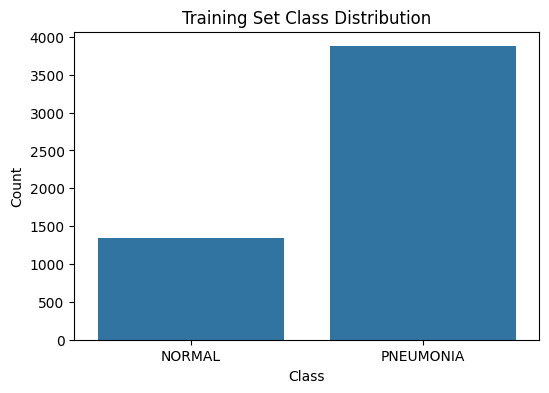

2026-05-14 17:56:23,762 - INFO - Saved class distribution plot to 'class_distribution.png'


In [30]:
# Plot Class Distribution (Integrated & RAM-Efficient)
classifier.plot_class_distribution()


## Sample Visualization
Displaying samples directly from the PyTorch Dataloader ensures we are seeing exactly what the model will see during training.


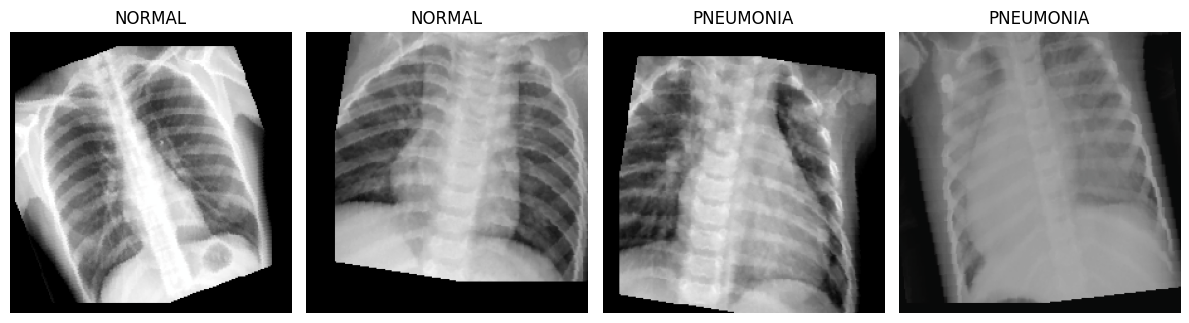

2026-05-14 17:56:29,902 - INFO - Saved sample images plot to 'sample_images.png'


In [31]:
# Preview Training Samples
classifier.plot_sample_images(num_images=4)


## Build Model
Initialize the pre-trained ResNet50 model and configure it for binary classification.


In [32]:
# Build Model
classifier.build_model()


2026-05-14 17:56:38,716 - INFO - Model built successfully!
2026-05-14 17:56:38,718 - INFO - Model parameters: 1,050,114


## Train Model
Execute the training loop. This will utilize DirectML for hardware acceleration if available.


In [ ]:
# Run Training (this will use DirectML for the Intel GPU!)
classifier.train(num_epochs=args.epochs, early_stopping_patience=args.early_stopping)


## Phase 2: Fine-Tuning
Now that the classifier head is trained, we "unfreeze" the deeper layers of the ResNet50 model. This allows the model to learn the specific features of medical X-rays while using class weights to ensure both Normal and Pneumonia cases are treated with equal importance.


In [33]:
# 1. Unfreeze the last few residual blocks
classifier.unfreeze_model(layers_to_unfreeze=2)

# 2. Train for a few more epochs with a lower learning rate
classifier.train(num_epochs=10, early_stopping_patience=3)


2026-05-14 17:56:48,919 - INFO - Unfreezing the last 2 layers of the model...
2026-05-14 17:56:48,922 - INFO - New trainable parameters: 23,113,218
2026-05-14 17:56:48,923 - INFO - Starting training for 10 epochs...
2026-05-14 17:56:48,925 - INFO - Epoch 1/10
2026-05-14 17:56:48,926 - INFO - ----------
Train:   0%|          | 0/326 [00:00<?, ?it/s]c:\Users\snype\anaconda3\envs\intel_open_veno\Lib\site-packages\torch\optim\adamw.py:529: UserWarning: The operator 'aten::lerp.Scalar_out' is not currently supported on the DML backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at C:\__w\1\s\pytorch-directml-plugin\torch_directml\csrc\dml\dml_cpu_fallback.cpp:17.)
  torch._foreach_lerp_(device_exp_avgs, device_grads, 1 - beta1)
Train: 100%|██████████| 326/326 [11:19<00:00,  2.08s/it, Loss=0.2626, Acc=0.8993]
2026-05-14 18:08:08,466 - INFO - Train Loss: 0.2626 Acc: 0.8993
Val: 100%|██████████| 1/1 [00:00<00:00,  1.29it/s, Loss=0.1926, A

## Evaluation & Diagnostics
Evaluate the fine-tuned model on the test set and generate comprehensive metrics including AUC and MCC.


In [34]:
# Evaluate the Model
results = classifier.evaluate(phase="test")


Evaluating on test: 100%|██████████| 39/39 [00:30<00:00,  1.29it/s]
2026-05-14 19:58:20,621 - INFO - Test Loss: 0.1877
2026-05-14 19:58:20,623 - INFO - Test Accuracy: 0.9407
2026-05-14 19:58:20,625 - INFO - 
Classification Report:
2026-05-14 19:58:20,635 - INFO -               precision    recall  f1-score   support

      NORMAL       0.98      0.86      0.92       234
   PNEUMONIA       0.92      0.99      0.95       390

    accuracy                           0.94       624
   macro avg       0.95      0.93      0.94       624
weighted avg       0.94      0.94      0.94       624

2026-05-14 19:58:20,637 - INFO - Matthews Correlation Coefficient (MCC): 0.8744
2026-05-14 19:58:20,644 - INFO - Area Under the Curve (AUC): 0.9876


## Plot Training History
Visualize the loss and accuracy curves over the training epochs.


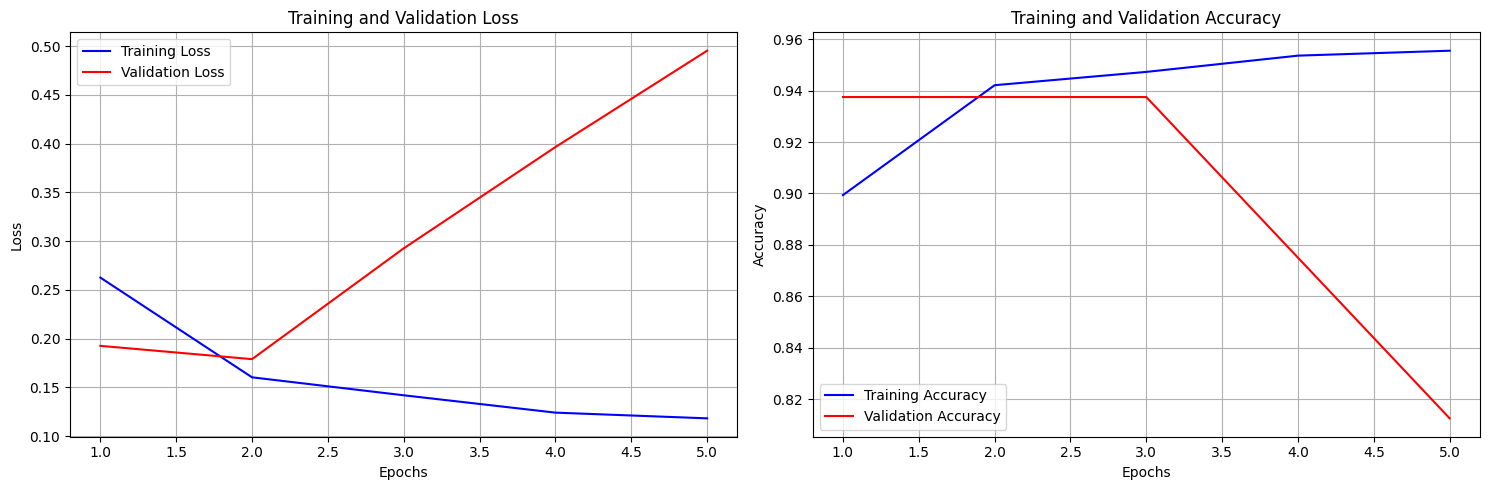

In [35]:
# Plot Training History
classifier.plot_training_history()


## Plot Confusion Matrix
Visualize the confusion matrix to see true positives, false positives, etc.


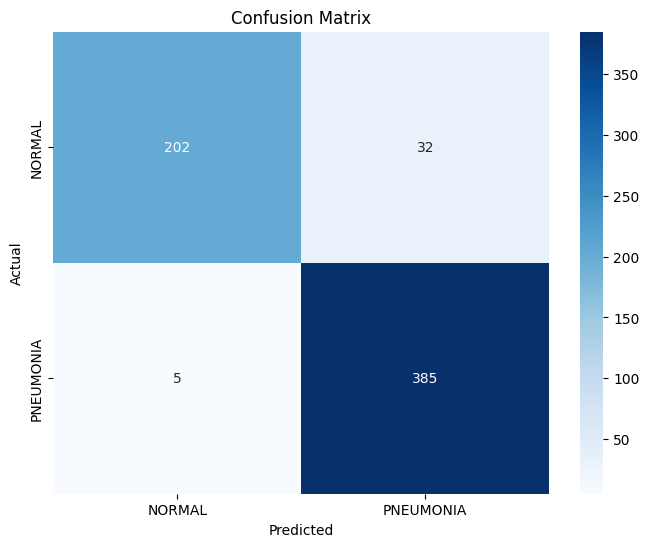

In [36]:
# Plot Confusion Matrix
classifier.plot_confusion_matrix(results['confusion_matrix'])


## Visualize Predictions
Display a grid of correctly and incorrectly classified images.


2026-05-14 20:02:54,336 - INFO - Collecting predictions for visualization...
2026-05-14 20:03:31,686 - INFO - Plotting correct predictions...


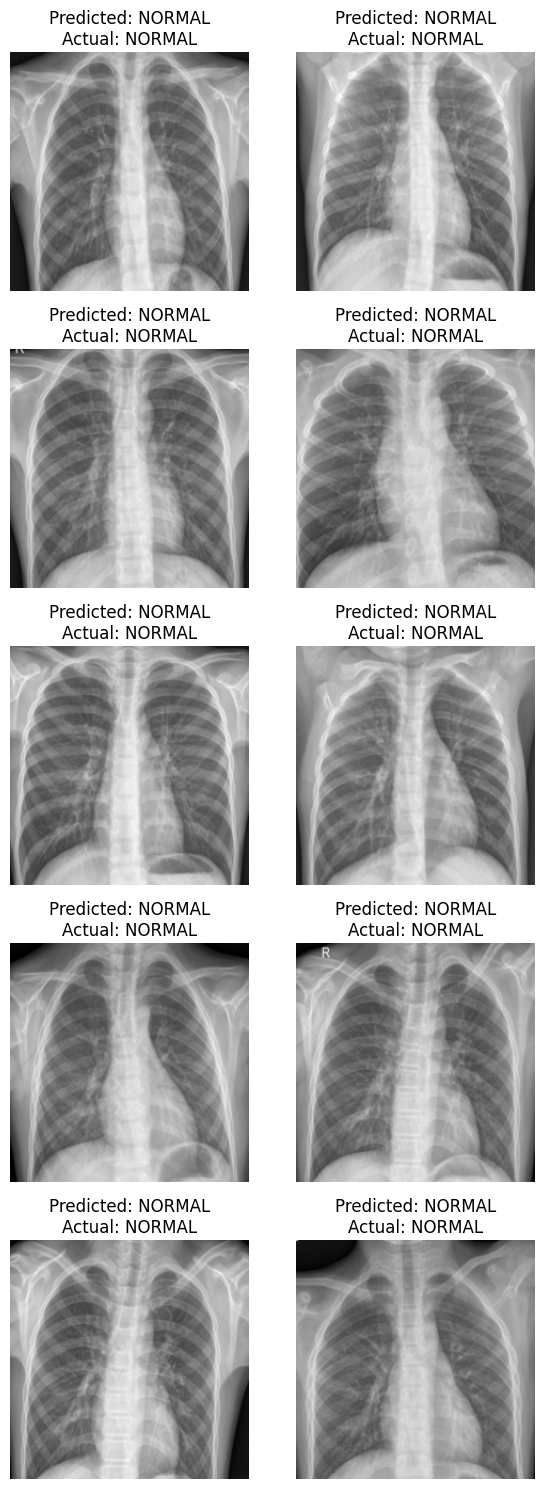

2026-05-14 20:03:33,017 - INFO - Plotting incorrect predictions...


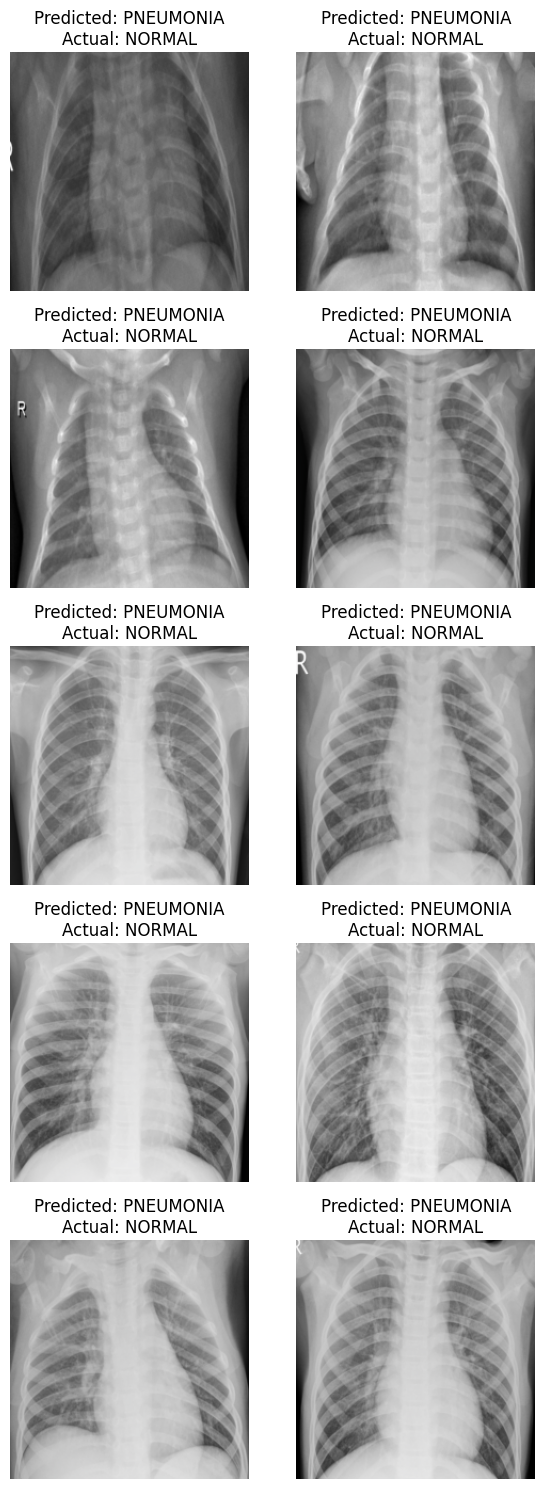

In [37]:
# Visualize Predictions (Correct vs Incorrect)
classifier.visualize_predictions(num_images=10)


## Single Image Inference
Use the trained model to predict the class of a specific image file.


2026-05-14 20:05:19,485 - INFO - Prediction for E:\data sets\chest_xray\test\NORMAL\IM-0001-0001.jpeg: NORMAL (99.77%)


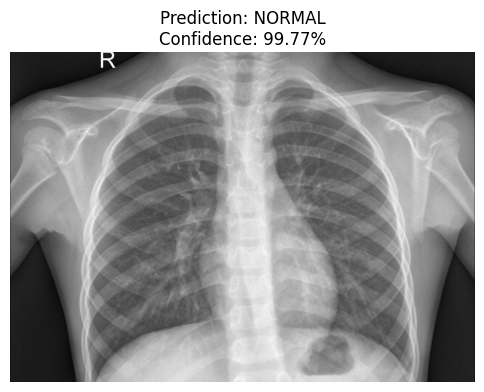

In [38]:
# Example: Predict a specific image from the test set
import os
test_normal_path = os.path.join(args.data_dir, "test", "NORMAL")
if os.path.exists(test_normal_path):
    sample_file = os.path.join(test_normal_path, os.listdir(test_normal_path)[0])
    result = classifier.predict(sample_file)
else:
    print("Please provide a valid image path to test.")


## Intel OpenVINO Inference
Intel OpenVINO is the most optimized way to run AI on Intel Iris Xe hardware. We export the model to the OpenVINO Intermediate Representation (IR) and run a fast inference.


2026-05-14 20:05:42,869 - INFO - Exporting model to OpenVINO IR format...
2026-05-14 20:05:46,181 - INFO - OpenVINO model saved to best_pneumonia_model_openvino.xml and best_pneumonia_model_openvino.bin
2026-05-14 20:06:04,069 - INFO - OpenVINO Prediction for E:\data sets\chest_xray\test\NORMAL\IM-0001-0001.jpeg: NORMAL (99.84%)


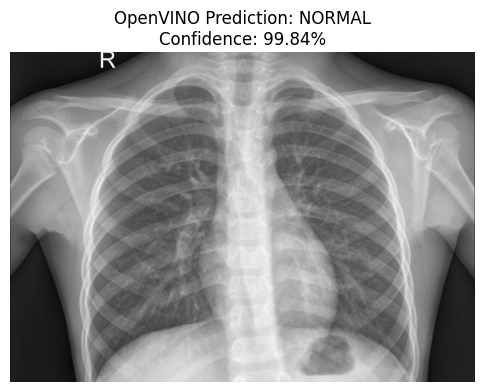

In [39]:
# 1. Export to OpenVINO
xml_path = classifier.export_openvino()

# 2. Run Inference using OpenVINO Runtime
if xml_path and os.path.exists(xml_path):
    # Use the same sample file from earlier
    classifier.predict_openvino(sample_file, xml_path)
else:
    print("OpenVINO export failed or package not installed.")


## Export Model
Export the model weights to PyTorch (.pth), ONNX (.onnx), and TorchScript (.pt) formats for production deployment.


In [ ]:
# Export Model for Production (ONNX & TorchScript)
classifier.export_model()
